<a href="https://www.kaggle.com/code/wafaaelhusseini/wine-food-pairing-dataset-generator?scriptVersionId=267565071" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


# 🍷 Rule-Based Wine & Food Pairing Dataset Generator

This notebook demonstrates how to **generate a realistic, structured dataset of wine and food pairings** using domain knowledge rather than raw scraping.  
It combines expert-inspired **knowledge bases** (for wines, foods, and cuisines) with **LLM-style logic** and rule-based scoring to create thousands of believable examples — both *good* and *bad* pairings.

You can use this dataset to:
- Train or test **recommendation models**
- Explore **pairing rules** via data analysis
- Build **food–wine matching apps** or demos
- Experiment with **synthetic data generation**

We’ll go step by step, explaining how each part works — from structured knowledge encoding to intelligent sampling and scoring.

---

### What you'll get
- Columns: `wine_type`, `wine_category`, `food_item`, `food_category`,
  `cuisine`, `pairing_quality`, `quality_label`, `description`
- Deterministic generation (seeded) with optional entropy
- Rules-based **compatibility scoring** from 1–5 with textual reasons
- A toggle to **append** to an existing CSV to grow the dataset over time
- Quick EDA charts


## 1) Configuration

In [2]:
import os, re, json, math, random, uuid, time
from datetime import datetime
from typing import Dict, List, Tuple
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm


RANDOM_SEED = 42
N_ROWS_TO_GENERATE = 5_000_000 #000
OUTPUT_PATH = "wine_food_pairings.csv"
APPEND_TO_EXISTING = True
RANDOM_ENTROPY = 7
REGIONAL_BIAS_STRENGTH = 3.0  # higher → more local wines, lower → more global mix
BATCH_SIZE = 100

USE_LLM = False

_base_seed = RANDOM_SEED if RANDOM_SEED is not None else random.randrange(1_000_000_000)
_run_entropy = int(time.time()) % 10 if RANDOM_SEED is None else RANDOM_ENTROPY
random.seed(_base_seed + _run_entropy)
# RUN_ID = f"run-{datetime.utcnow().strftime('%Y%m%d-%H%M%S')}"
print("Seed:", _base_seed, "Entropy:", _run_entropy)#, "Run ID:", RUN_ID)


Seed: 42 Entropy: 7


## 2) Knowledge Base (Wines, Cuisines, Dishes)
### 🧠 Wine Knowledge Base
We start by defining a detailed **dictionary of wine styles**.  
Each wine entry includes:
- **Category** (red, white, rosé, sparkling, dessert)
- **Sensory attributes** like tannin, acidity, body, and sweetness
- **Dominant flavors** and example regions
- **Typical and avoid pairings**
- A **pairing archetype** (e.g. “Bold Red”, “Crisp White”) that drives compatibility rules

This knowledge base represents *expert-like knowledge* — using carefully curated logic reflecting classical pairing principles.

Later, this structured format lets us reason algorithmically about matches (e.g., “high tannin complements fat”, “sweetness softens spice”).



In [3]:
WINES = {

    # ---------- RED WINES ----------
    "Cabernet Sauvignon": {
        "category": "Red",
        "style": "Full-bodied, tannic, dark fruit, often oaked.",
        "tannin": "high",
        "acidity": "med",
        "body": "full",
        "sweetness": "dry",
        "dominant_flavors": ["blackcurrant", "black cherry", "cedar", "graphite"],
        "origin_examples": ["Bordeaux (France)", "Napa Valley (USA)", "Coonawarra (Australia)"],
        "typical_pairings": ["steak", "lamb chops", "aged cheddar", "short ribs"],
        "avoid_with": ["spicy curries", "delicate fish", "salads"],
        "pairing_archetype": "Bold Red"
    },

    "Merlot": {
        "category": "Red",
        "style": "Medium-bodied, soft tannins, plum and chocolate notes.",
        "tannin": "med",
        "acidity": "med",
        "body": "med",
        "sweetness": "dry",
        "dominant_flavors": ["plum", "chocolate", "herb", "black cherry"],
        "origin_examples": ["Bordeaux (France)", "California (USA)", "Chile"],
        "typical_pairings": ["roast chicken", "pork loin", "mushroom dishes", "pizza"],
        "avoid_with": ["very spicy foods", "oysters"],
        "pairing_archetype": "Smooth Red"
    },

    "Pinot Noir": {
        "category": "Red",
        "style": "Light, elegant, high acidity, earthy red fruit.",
        "tannin": "low",
        "acidity": "high",
        "body": "light",
        "sweetness": "dry",
        "dominant_flavors": ["cherry", "strawberry", "mushroom", "earth"],
        "origin_examples": ["Burgundy (France)", "Oregon (USA)", "New Zealand"],
        "typical_pairings": ["duck", "salmon", "mushroom risotto", "roast chicken"],
        "avoid_with": ["spicy curry", "blue cheese"],
        "pairing_archetype": "Earthy Red"
    },

    "Syrah/Shiraz": {
        "category": "Red",
        "style": "Full-bodied, peppery, dark fruit, often smoky.",
        "tannin": "med_high",
        "acidity": "med",
        "body": "full",
        "sweetness": "dry",
        "dominant_flavors": ["blackberry", "pepper", "smoke", "violet"],
        "origin_examples": ["Rhône Valley (France)", "Barossa (Australia)"],
        "typical_pairings": ["grilled lamb", "bbq meats", "pepper steak"],
        "avoid_with": ["delicate seafood", "light salads"],
        "pairing_archetype": "Bold Red"
    },

    "Malbec": {
        "category": "Red",
        "style": "Full-bodied, plush, ripe dark fruit.",
        "tannin": "med",
        "acidity": "med",
        "body": "full",
        "sweetness": "dry",
        "dominant_flavors": ["plum", "cocoa", "blackberry"],
        "origin_examples": ["Mendoza (Argentina)", "Cahors (France)"],
        "typical_pairings": ["steak", "empanadas", "bbq ribs", "chorizo"],
        "avoid_with": ["delicate fish", "spicy Thai curry"],
        "pairing_archetype": "Bold Red"
    },

    "Zinfandel": {
        "category": "Red",
        "style": "Jammy, spicy, fruit-forward.",
        "tannin": "med",
        "acidity": "med",
        "body": "full",
        "sweetness": "dry",
        "dominant_flavors": ["blackberry jam", "spice", "pepper", "vanilla"],
        "origin_examples": ["California (USA)", "Puglia (Italy, Primitivo)"],
        "typical_pairings": ["bbq ribs", "pepperoni pizza", "burgers", "chili"],
        "avoid_with": ["sushi", "oysters", "light salads"],
        "pairing_archetype": "Fruity Red"
    },

    "Sangiovese": {
        "category": "Red",
        "style": "Medium-bodied, high acidity, cherry and herbs.",
        "tannin": "med_high",
        "acidity": "high",
        "body": "med",
        "sweetness": "dry",
        "dominant_flavors": ["cherry", "tomato", "oregano"],
        "origin_examples": ["Tuscany (Italy)"],
        "typical_pairings": ["tomato pasta", "pizza", "bolognese", "grilled meats"],
        "avoid_with": ["very sweet dishes", "sushi"],
        "pairing_archetype": "Earthy Red"
    },

    "Nebbiolo": {
        "category": "Red",
        "style": "High tannin, high acid, delicate aromatics.",
        "tannin": "high",
        "acidity": "high",
        "body": "med",
        "sweetness": "dry",
        "dominant_flavors": ["tar", "rose", "cherry"],
        "origin_examples": ["Piedmont (Italy)"],
        "typical_pairings": ["truffle pasta", "braised beef", "aged cheese"],
        "avoid_with": ["spicy foods", "seafood"],
        "pairing_archetype": "Tannic Red"
    },

    "Tempranillo": {
        "category": "Red",
        "style": "Medium-bodied, rustic, tobacco and cherry.",
        "tannin": "med",
        "acidity": "med",
        "body": "med",
        "sweetness": "dry",
        "dominant_flavors": ["cherry", "tobacco", "leather"],
        "origin_examples": ["Rioja (Spain)"],
        "typical_pairings": ["paella", "roast lamb", "tapas", "aged manchego"],
        "avoid_with": ["sushi", "spicy stir-fry"],
        "pairing_archetype": "Rustic Red"
    },

    "Grenache": {
        "category": "Red",
        "style": "Soft, fruity, aromatic red often used in blends.",
        "tannin": "low",
        "acidity": "med",
        "body": "med",
        "sweetness": "dry",
        "dominant_flavors": ["strawberry", "white pepper", "herb"],
        "origin_examples": ["Southern Rhône", "Spain (Garnacha)"],
        "typical_pairings": ["roast chicken", "charcuterie", "tapas"],
        "avoid_with": ["very spicy foods"],
        "pairing_archetype": "Smooth Red"
    },

    "Barbera": {
        "category": "Red",
        "style": "High acid, low tannin, red fruit and spice.",
        "tannin": "low",
        "acidity": "high",
        "body": "med",
        "sweetness": "dry",
        "dominant_flavors": ["cherry", "raspberry", "spice"],
        "origin_examples": ["Piedmont (Italy)"],
        "typical_pairings": ["tomato pasta", "pizza", "charcuterie"],
        "avoid_with": ["desserts", "sweet sauces"],
        "pairing_archetype": "Bright Red"
    },

    "Gamay (Beaujolais)": {
        "category": "Red",
        "style": "Light-bodied, fruity, low tannin.",
        "tannin": "low",
        "acidity": "high",
        "body": "light",
        "sweetness": "dry",
        "dominant_flavors": ["strawberry", "banana", "violet"],
        "origin_examples": ["Beaujolais (France)"],
        "typical_pairings": ["turkey", "ham", "salads", "charcuterie"],
        "avoid_with": ["steak", "chocolate cake"],
        "pairing_archetype": "Light Red"
    },

    # ---------- WHITE WINES ----------
    "Chardonnay": {
        "category": "White",
        "style": "Rich, creamy, often oaked.",
        "tannin": "none",
        "acidity": "med",
        "body": "full",
        "sweetness": "dry",
        "dominant_flavors": ["butter", "oak", "apple", "vanilla"],
        "origin_examples": ["Burgundy", "California"],
        "typical_pairings": ["lobster", "roast chicken", "buttery pasta"],
        "avoid_with": ["spicy dishes", "sashimi"],
        "pairing_archetype": "Rich White"
    },

    "Sauvignon Blanc": {
        "category": "White",
        "style": "Crisp, herbal, citrus-driven.",
        "tannin": "none",
        "acidity": "high",
        "body": "light",
        "sweetness": "dry",
        "dominant_flavors": ["lime", "gooseberry", "grass"],
        "origin_examples": ["Loire Valley", "New Zealand"],
        "typical_pairings": ["goat cheese", "seafood", "salads"],
        "avoid_with": ["heavy steak", "desserts"],
        "pairing_archetype": "Crisp White"
    },

    "Riesling (dry)": {
        "category": "White",
        "style": "Aromatic, high acid, mineral-driven.",
        "tannin": "none",
        "acidity": "high",
        "body": "light",
        "sweetness": "off-dry",
        "dominant_flavors": ["lime", "green apple", "petrol"],
        "origin_examples": ["Germany", "Alsace"],
        "typical_pairings": ["sushi", "spicy Thai food", "pork"],
        "avoid_with": ["heavy beef", "chocolate desserts"],
        "pairing_archetype": "Aromatic White"
    },

    "Chenin Blanc": {
        "category": "White",
        "style": "Versatile, can be dry or off-dry, apple and honey.",
        "tannin": "none",
        "acidity": "high",
        "body": "med",
        "sweetness": "off-dry",
        "dominant_flavors": ["apple", "quince", "honey"],
        "origin_examples": ["Loire Valley", "South Africa"],
        "typical_pairings": ["fish curry", "cheese fondue", "poultry"],
        "avoid_with": ["heavy steak", "spicy vindaloo"],
        "pairing_archetype": "Versatile White"
    },

    "Grüner Veltliner": {
        "category": "White",
        "style": "Peppery, citrus, mineral-driven Austrian white.",
        "tannin": "none",
        "acidity": "high",
        "body": "light",
        "sweetness": "dry",
        "dominant_flavors": ["lemon", "white pepper", "green apple"],
        "origin_examples": ["Austria"],
        "typical_pairings": ["schnitzel", "salads", "seafood"],
        "avoid_with": ["sweet desserts"],
        "pairing_archetype": "Crisp White"
    },

    "Albariño": {
        "category": "White",
        "style": "Zesty, saline, citrusy.",
        "tannin": "none",
        "acidity": "high",
        "body": "light",
        "sweetness": "dry",
        "dominant_flavors": ["lime", "sea spray", "peach"],
        "origin_examples": ["Rías Baixas (Spain)", "Portugal (Vinho Verde)"],
        "typical_pairings": ["shellfish", "ceviche", "sushi"],
        "avoid_with": ["steak", "desserts"],
        "pairing_archetype": "Crisp White"
    },

    "Viognier": {
        "category": "White",
        "style": "Rich, floral, apricot and honeysuckle.",
        "tannin": "none",
        "acidity": "low_med",
        "body": "med_full",
        "sweetness": "dry",
        "dominant_flavors": ["apricot", "peach", "floral"],
        "origin_examples": ["Rhône Valley", "California"],
        "typical_pairings": ["roast chicken", "lobster", "creamy sauces"],
        "avoid_with": ["spicy foods"],
        "pairing_archetype": "Rich White"
    },

    "Gewürztraminer": {
        "category": "White",
        "style": "Aromatic, floral, lychee and spice.",
        "tannin": "none",
        "acidity": "low",
        "body": "med",
        "sweetness": "off-dry",
        "dominant_flavors": ["lychee", "rose", "ginger"],
        "origin_examples": ["Alsace", "Germany"],
        "typical_pairings": ["spicy Asian dishes", "strong cheeses"],
        "avoid_with": ["delicate seafood", "steak"],
        "pairing_archetype": "Aromatic White"
    },

    "Torrontés": {
        "category": "White",
        "style": "Floral, aromatic, dry Argentinian white.",
        "tannin": "none",
        "acidity": "med",
        "body": "light",
        "sweetness": "dry",
        "dominant_flavors": ["orange blossom", "peach", "lemon peel"],
        "origin_examples": ["Argentina"],
        "typical_pairings": ["ceviche", "sushi", "light curries"],
        "avoid_with": ["red meat"],
        "pairing_archetype": "Aromatic White"
    },

    # ---------- ROSÉ ----------
    "Provence Rosé": {
        "category": "Rosé",
        "style": "Dry, pale, refreshing.",
        "tannin": "low",
        "acidity": "med",
        "body": "light",
        "sweetness": "dry",
        "dominant_flavors": ["strawberry", "melon", "rose petal"],
        "origin_examples": ["Provence (France)"],
        "typical_pairings": ["seafood", "salads", "light pasta"],
        "avoid_with": ["heavy beef stews"],
        "pairing_archetype": "Dry Rosé"
    },

    "White Zinfandel": {
        "category": "Rosé",
        "style": "Sweet, fruity, easy-drinking.",
        "tannin": "low",
        "acidity": "low",
        "body": "light",
        "sweetness": "sweet",
        "dominant_flavors": ["strawberry", "candy", "melon"],
        "origin_examples": ["California"],
        "typical_pairings": ["brunch dishes", "spicy food", "fruit desserts"],
        "avoid_with": ["steak", "aged cheese"],
        "pairing_archetype": "Sweet Rosé"
    },

    # ---------- SPARKLING ----------
    "Champagne": {
        "category": "Sparkling",
        "style": "High acid, toasty, crisp bubbles.",
        "tannin": "none",
        "acidity": "high",
        "body": "light",
        "sweetness": "brut",
        "dominant_flavors": ["lemon", "brioche", "almond"],
        "origin_examples": ["Champagne (France)"],
        "typical_pairings": ["oysters", "fried chicken", "caviar"],
        "avoid_with": ["heavy red meats"],
        "pairing_archetype": "Sparkling Wine"
    },

    "Cava": {
        "category": "Sparkling",
        "style": "Spanish sparkling, dry and crisp.",
        "tannin": "none",
        "acidity": "high",
        "body": "light",
        "sweetness": "brut",
        "dominant_flavors": ["green apple", "lemon", "biscuit"],
        "origin_examples": ["Catalonia (Spain)"],
        "typical_pairings": ["tapas", "seafood", "fried foods"],
        "avoid_with": ["steak"],
        "pairing_archetype": "Sparkling Wine"
    },

    # ---------- DESSERT & FORTIFIED ----------
    "Port": {
        "category": "Fortified",
        "style": "Sweet, rich, fortified red.",
        "tannin": "med",
        "acidity": "low",
        "body": "full",
        "sweetness": "sweet",
        "dominant_flavors": ["raisin", "nut", "chocolate"],
        "origin_examples": ["Douro (Portugal)"],
        "typical_pairings": ["chocolate desserts", "blue cheese", "nuts"],
        "avoid_with": ["spicy food", "salads"],
        "pairing_archetype": "Sweet Fortified"
    },

    "Sauternes": {
        "category": "Dessert",
        "style": "Lusciously sweet with balancing acidity.",
        "tannin": "none",
        "acidity": "high",
        "body": "full",
        "sweetness": "sweet",
        "dominant_flavors": ["honey", "apricot", "botrytis"],
        "origin_examples": ["Bordeaux (France)"],
        "typical_pairings": ["foie gras", "blue cheese", "fruit tart"],
        "avoid_with": ["spicy curries", "savory beef dishes"],
        "pairing_archetype": "Sweet Dessert"
    },

    "Madeira": {
        "category": "Fortified",
        "style": "Nutty, caramelized fortified wine.",
        "tannin": "low",
        "acidity": "high",
        "body": "full",
        "sweetness": "sweet",
        "dominant_flavors": ["toffee", "almond", "raisin"],
        "origin_examples": ["Madeira (Portugal)"],
        "typical_pairings": ["nuts", "hard cheese", "desserts"],
        "avoid_with": ["spicy food"],
        "pairing_archetype": "Sweet Fortified"
    },

    "Ice Wine": {
        "category": "Dessert",
        "style": "Intensely sweet wine made from frozen grapes.",
        "tannin": "none",
        "acidity": "high",
        "body": "full",
        "sweetness": "sweet",
        "dominant_flavors": ["honey", "apricot", "mango"],
        "origin_examples": ["Canada", "Germany"],
        "typical_pairings": ["fruit tart", "cheesecake", "blue cheese"],
        "avoid_with": ["savory meat dishes"],
        "pairing_archetype": "Sweet Dessert"
    },
}

### 🍽️ Food Knowledge Base

Next, we define the **Food Knowledge Base**, which classifies foods by *flavor and texture*, not just by name.

Each entry includes:
- **Category and subcategories** (e.g. Red Meat → Beef, Lamb)
- **Flavor intensity vector** — fat, acid, sweetness, salt, spice, umami, smoke (scaled 0–1)
- **Example dishes** and **texture type**
- **Pairing archetypes** that work well (and those that don’t)

This structured approach lets us connect sensory science with rule-based pairing logic — for example:
- High-fat foods balance with tannic reds
- Spicy foods prefer slightly sweet or aromatic wines
- Acidic foods demand wines with matching acidity

This design also allows later numerical modeling (the flavor profiles can serve as numeric features).


In [4]:
FOODS = {

    # ---------- RED MEATS ----------
    "Red Meat": {
        "category": "Protein",
        "subcategories": ["Beef", "Lamb", "Venison"],
        "flavor_profile": {"fat": 0.9, "acid": 0.1, "sweet": 0.0, "salt": 0.4, "spice": 0.3, "umami": 0.8, "smoke": 0.5},
        "texture": "heavy",
        "typical_ingredients": ["steak", "lamb chops", "roast beef", "venison", "short ribs"],
        "example_dishes": ["grilled ribeye", "roast lamb", "beef stew", "bbq brisket"],
        "pairs_well_with": ["Bold Red", "Tannic Red"],
        "avoid_with": ["Sweet White", "Delicate White"]
    },

    # ---------- PORK ----------
    "Pork": {
        "category": "Protein",
        "subcategories": ["Ham", "Bacon", "Pork Chop", "Prosciutto"],
        "flavor_profile": {"fat": 0.6, "acid": 0.1, "sweet": 0.1, "salt": 0.6, "spice": 0.2, "umami": 0.7, "smoke": 0.3},
        "texture": "medium",
        "typical_ingredients": ["pork loin", "prosciutto", "bacon"],
        "example_dishes": ["pork tenderloin", "carbonara", "bacon burger"],
        "pairs_well_with": ["Smooth Red", "Rich White"],
        "avoid_with": ["Sweet Dessert", "Tannic Red"]
    },

    # ---------- POULTRY ----------
    "Poultry": {
        "category": "Protein",
        "subcategories": ["Chicken", "Turkey", "Duck"],
        "flavor_profile": {"fat": 0.4, "acid": 0.1, "sweet": 0.1, "salt": 0.4, "spice": 0.2, "umami": 0.5, "smoke": 0.3},
        "texture": "medium",
        "typical_ingredients": ["roast chicken", "duck breast", "turkey", "coq au vin"],
        "example_dishes": ["roast chicken with herbs", "duck à l’orange", "chicken curry"],
        "pairs_well_with": ["Earthy Red", "Rich White", "Rosé"],
        "avoid_with": ["Sweet Dessert"]
    },

    # ---------- SEAFOOD ----------
    "Seafood": {
        "category": "Protein",
        "subcategories": ["Fish", "Shellfish"],
        "flavor_profile": {"fat": 0.2, "acid": 0.2, "sweet": 0.0, "salt": 0.5, "spice": 0.1, "umami": 0.6, "smoke": 0.1},
        "texture": "light",
        "typical_ingredients": ["salmon", "tuna", "cod", "shrimp", "scallop", "lobster"],
        "example_dishes": ["grilled salmon", "shrimp scampi", "fish tacos", "oysters"],
        "pairs_well_with": ["Crisp White", "Sparkling Wine", "Light Red"],
        "avoid_with": ["Tannic Red", "Sweet Dessert"]
    },

    # ---------- VEGETARIAN ----------
    "Vegetarian": {
        "category": "Plant-Based",
        "subcategories": ["Tofu", "Mushrooms", "Legumes", "Vegetables"],
        "flavor_profile": {"fat": 0.2, "acid": 0.2, "sweet": 0.2, "salt": 0.3, "spice": 0.2, "umami": 0.4, "smoke": 0.0},
        "texture": "light",
        "typical_ingredients": ["tofu", "eggplant", "zucchini", "mushroom", "beans"],
        "example_dishes": ["mushroom risotto", "stir-fried tofu", "vegetable curry"],
        "pairs_well_with": ["Earthy Red", "Crisp White"],
        "avoid_with": ["Sweet Dessert"]
    },

    # ---------- CHEESE ----------
    "Cheese": {
        "category": "Dairy",
        "subcategories": ["Hard", "Soft", "Blue", "Goat"],
        "flavor_profile": {"fat": 0.8, "acid": 0.1, "sweet": 0.0, "salt": 0.6, "spice": 0.0, "umami": 0.8, "smoke": 0.0},
        "texture": "creamy",
        "typical_ingredients": ["brie", "cheddar", "parmesan", "gorgonzola", "chèvre"],
        "example_dishes": ["cheese platter", "mac and cheese", "fondue"],
        "pairs_well_with": ["Rich White", "Sweet Fortified"],
        "avoid_with": ["Tannic Red (for soft cheeses)"]
    },

    # ---------- CREAMY / DAIRY ----------
    "Creamy": {
        "category": "Sauce/Texture",
        "subcategories": ["Cream Sauce", "Butter Sauce"],
        "flavor_profile": {"fat": 0.8, "acid": 0.1, "sweet": 0.1, "salt": 0.4, "spice": 0.1, "umami": 0.5, "smoke": 0.0},
        "texture": "creamy",
        "typical_ingredients": ["cream", "butter", "béchamel", "alfredo"],
        "example_dishes": ["carbonara", "alfredo pasta", "cream of mushroom soup"],
        "pairs_well_with": ["Rich White", "Smooth Red"],
        "avoid_with": ["Crisp White", "Tannic Red"]
    },

    # ---------- SPICY ----------
    "Spicy": {
        "category": "Flavor Profile",
        "subcategories": ["Curry", "Chili", "Hot Pot"],
        "flavor_profile": {"fat": 0.3, "acid": 0.2, "sweet": 0.1, "salt": 0.4, "spice": 1.0, "umami": 0.5, "smoke": 0.0},
        "texture": "medium",
        "typical_ingredients": ["chili", "curry", "pepper", "sriracha"],
        "example_dishes": ["Thai curry", "Indian vindaloo", "Sichuan noodles"],
        "pairs_well_with": ["Sweet White", "Aromatic White", "Rosé"],
        "avoid_with": ["Tannic Red", "High Alcohol"]
    },

    # ---------- DESSERTS ----------
    "Dessert": {
        "category": "Sweet Dish",
        "subcategories": ["Cake", "Chocolate", "Fruit Tart", "Ice Cream"],
        "flavor_profile": {"fat": 0.4, "acid": 0.2, "sweet": 1.0, "salt": 0.2, "spice": 0.1, "umami": 0.0, "smoke": 0.0},
        "texture": "creamy",
        "typical_ingredients": ["chocolate", "vanilla", "fruit", "caramel"],
        "example_dishes": ["chocolate mousse", "lemon tart", "cheesecake", "sorbet"],
        "pairs_well_with": ["Sweet Dessert", "Sweet Fortified"],
        "avoid_with": ["Dry Red", "Crisp White"]
    },

    # ---------- SALTY / SNACK ----------
    "Salty Snack": {
        "category": "Snack",
        "subcategories": ["Charcuterie", "Nuts", "Olives"],
        "flavor_profile": {"fat": 0.6, "acid": 0.1, "sweet": 0.0, "salt": 1.0, "spice": 0.1, "umami": 0.5, "smoke": 0.2},
        "texture": "crisp",
        "typical_ingredients": ["nuts", "prosciutto", "olives", "chips"],
        "example_dishes": ["charcuterie board", "mixed nuts", "olives and cheese"],
        "pairs_well_with": ["Sparkling Wine", "Smooth Red"],
        "avoid_with": ["Sweet Dessert"]
    },

    # ---------- ACIDIC ----------
    "Acidic": {
        "category": "Flavor Profile",
        "subcategories": ["Tomato-Based", "Citrus-Based"],
        "flavor_profile": {"fat": 0.1, "acid": 1.0, "sweet": 0.1, "salt": 0.3, "spice": 0.2, "umami": 0.3, "smoke": 0.0},
        "texture": "light",
        "typical_ingredients": ["tomato", "lemon", "vinegar"],
        "example_dishes": ["caprese salad", "gazpacho", "citrus salad"],
        "pairs_well_with": ["High Acid White", "Earthy Red"],
        "avoid_with": ["Low Acid Rich Whites"]
    },

    # ---------- SMOKY ----------
    "Smoky BBQ": {
        "category": "Cooking Style",
        "subcategories": ["Grilled", "Smoked", "Barbecue"],
        "flavor_profile": {"fat": 0.7, "acid": 0.1, "sweet": 0.2, "salt": 0.5, "spice": 0.4, "umami": 0.7, "smoke": 1.0},
        "texture": "heavy",
        "typical_ingredients": ["bbq sauce", "grilled meats", "smoked brisket"],
        "example_dishes": ["bbq ribs", "smoked sausage", "grilled burger"],
        "pairs_well_with": ["Fruity Red", "Bold Red"],
        "avoid_with": ["Delicate White", "Sweet Dessert"]
    },
}

### 🌍 Cuisine Knowledge Base

Pairing doesn’t happen in a vacuum — regional and cultural context matters.  
Here, we define a **Cuisine Knowledge Base** that captures 18 global cuisines, each with:

- **Flavor intensity** and typical taste balance (fat, acid, spice, umami)
- **Signature ingredients** and example dishes
- **Recommended and avoided wine archetypes**
- **Regional tags** (Europe, Asia, Americas, etc.)

This allows the generator to:
- Produce coherent dish–cuisine combinations
- Learn *regional bias* (e.g., Italian cuisine → Italian wines)
- Mix local and cross-cultural pairing examples for realism


In [5]:
CUISINES = {

    # ---------- EUROPE ----------
    "Italian": {
        "region": "Europe",
        "profile": "Herbal, tomato-based, olive oil, and cheese-rich dishes.",
        "intensity": "medium",
        "flavor_profile": {"fat": 0.5, "acid": 0.7, "sweet": 0.1, "salt": 0.6, "spice": 0.2, "umami": 0.8},
        "signature_ingredients": ["tomato", "basil", "olive oil", "garlic", "cheese"],
        "signature_dishes": ["spaghetti bolognese", "risotto", "lasagna", "caprese salad"],
        "best_wine_archetypes": ["Earthy Red", "Crisp White", "Rich White"],
        "avoid_wine_archetypes": ["Sweet Dessert"]
    },

    "French": {
        "region": "Europe",
        "profile": "Elegant, sauce-driven cuisine with balance of fat and acidity.",
        "intensity": "medium",
        "flavor_profile": {"fat": 0.6, "acid": 0.5, "sweet": 0.2, "salt": 0.5, "spice": 0.2, "umami": 0.6},
        "signature_ingredients": ["butter", "cream", "herbs", "wine reductions"],
        "signature_dishes": ["coq au vin", "duck confit", "bouillabaisse", "ratatouille"],
        "best_wine_archetypes": ["Earthy Red", "Rich White", "Sparkling Wine"],
        "avoid_wine_archetypes": ["Sweet Fortified"]
    },

    "Spanish": {
        "region": "Europe",
        "profile": "Rustic, smoky, with olive oil and paprika-driven flavors.",
        "intensity": "bold",
        "flavor_profile": {"fat": 0.6, "acid": 0.4, "sweet": 0.1, "salt": 0.7, "spice": 0.4, "umami": 0.7},
        "signature_ingredients": ["olive oil", "paprika", "garlic", "ham"],
        "signature_dishes": ["paella", "tapas", "chorizo stew"],
        "best_wine_archetypes": ["Rustic Red", "Fruity Red", "Crisp White"],
        "avoid_wine_archetypes": ["Sweet Dessert"]
    },

    "German": {
        "region": "Europe",
        "profile": "Savory, hearty, with fat, acid, and some sweetness.",
        "intensity": "medium",
        "flavor_profile": {"fat": 0.7, "acid": 0.5, "sweet": 0.2, "salt": 0.6, "spice": 0.3, "umami": 0.5},
        "signature_ingredients": ["sausages", "potatoes", "mustard", "vinegar"],
        "signature_dishes": ["schnitzel", "bratwurst", "sauerbraten"],
        "best_wine_archetypes": ["Crisp White", "Aromatic White"],
        "avoid_wine_archetypes": ["Tannic Red"]
    },

    "Greek": {
        "region": "Europe",
        "profile": "Mediterranean flavors with olive oil, herbs, and citrus.",
        "intensity": "medium",
        "flavor_profile": {"fat": 0.5, "acid": 0.6, "sweet": 0.1, "salt": 0.5, "spice": 0.2, "umami": 0.5},
        "signature_ingredients": ["olive oil", "oregano", "lemon", "feta cheese"],
        "signature_dishes": ["moussaka", "souvlaki", "Greek salad"],
        "best_wine_archetypes": ["Crisp White", "Smooth Red", "Rosé"],
        "avoid_wine_archetypes": ["Sweet Fortified"]
    },

    # ---------- ASIA ----------
    "Japanese": {
        "region": "Asia",
        "profile": "Delicate balance of umami and acidity; subtle flavors.",
        "intensity": "light",
        "flavor_profile": {"fat": 0.3, "acid": 0.5, "sweet": 0.1, "salt": 0.5, "spice": 0.0, "umami": 0.8},
        "signature_ingredients": ["soy sauce", "dashi", "ginger", "seaweed"],
        "signature_dishes": ["sushi", "ramen", "tempura", "teriyaki"],
        "best_wine_archetypes": ["Crisp White", "Aromatic White", "Sparkling Wine"],
        "avoid_wine_archetypes": ["Tannic Red"]
    },

    "Chinese (Sichuan)": {
        "region": "Asia",
        "profile": "Spicy, oily, umami-rich with peppercorn heat.",
        "intensity": "bold",
        "flavor_profile": {"fat": 0.7, "acid": 0.3, "sweet": 0.2, "salt": 0.6, "spice": 1.0, "umami": 0.9},
        "signature_ingredients": ["chili", "Sichuan pepper", "soy sauce", "ginger"],
        "signature_dishes": ["kung pao chicken", "mapo tofu", "dan dan noodles"],
        "best_wine_archetypes": ["Sweet White", "Aromatic White", "Rosé"],
        "avoid_wine_archetypes": ["Tannic Red", "High Alcohol Reds"]
    },

    "Thai": {
        "region": "Asia",
        "profile": "Spicy, aromatic, sweet-sour balance with coconut and herbs.",
        "intensity": "bold",
        "flavor_profile": {"fat": 0.5, "acid": 0.6, "sweet": 0.4, "salt": 0.5, "spice": 0.9, "umami": 0.6},
        "signature_ingredients": ["lemongrass", "lime", "chili", "coconut milk"],
        "signature_dishes": ["green curry", "pad thai", "som tam"],
        "best_wine_archetypes": ["Sweet White", "Aromatic White", "Rosé"],
        "avoid_wine_archetypes": ["Tannic Red"]
    },

    "Indian": {
        "region": "Asia",
        "profile": "Rich, spicy, often creamy and aromatic dishes.",
        "intensity": "very_bold",
        "flavor_profile": {"fat": 0.6, "acid": 0.3, "sweet": 0.3, "salt": 0.6, "spice": 1.0, "umami": 0.7},
        "signature_ingredients": ["garam masala", "turmeric", "yogurt", "ginger"],
        "signature_dishes": ["chicken tikka masala", "vindaloo", "dal makhani"],
        "best_wine_archetypes": ["Sweet White", "Aromatic White"],
        "avoid_wine_archetypes": ["Tannic Red", "High Alcohol Red"]
    },

    "Korean": {
        "region": "Asia",
        "profile": "Fermented, spicy, and umami-heavy cuisine.",
        "intensity": "bold",
        "flavor_profile": {"fat": 0.5, "acid": 0.4, "sweet": 0.3, "salt": 0.6, "spice": 0.9, "umami": 0.9},
        "signature_ingredients": ["gochujang", "kimchi", "garlic", "soy sauce"],
        "signature_dishes": ["bibimbap", "bulgogi", "kimchi stew"],
        "best_wine_archetypes": ["Sweet White", "Rosé"],
        "avoid_wine_archetypes": ["Tannic Red"]
    },

    "Vietnamese": {
        "region": "Asia",
        "profile": "Light, fresh, herbal with sweet-sour balance.",
        "intensity": "medium",
        "flavor_profile": {"fat": 0.3, "acid": 0.7, "sweet": 0.3, "salt": 0.4, "spice": 0.5, "umami": 0.5},
        "signature_ingredients": ["fish sauce", "lime", "mint", "basil"],
        "signature_dishes": ["pho", "spring rolls", "bun cha"],
        "best_wine_archetypes": ["Crisp White", "Aromatic White"],
        "avoid_wine_archetypes": ["Tannic Red"]
    },

    # ---------- AMERICAS ----------
    "American BBQ": {
        "region": "North America",
        "profile": "Smoky, sweet-savory grilled meats and sauces.",
        "intensity": "bold",
        "flavor_profile": {"fat": 0.8, "acid": 0.2, "sweet": 0.4, "salt": 0.7, "spice": 0.4, "umami": 0.7},
        "signature_ingredients": ["smoked meats", "bbq sauce", "spice rubs"],
        "signature_dishes": ["pulled pork", "brisket", "ribs", "burgers"],
        "best_wine_archetypes": ["Fruity Red", "Bold Red"],
        "avoid_wine_archetypes": ["Crisp White"]
    },

    "Mexican": {
        "region": "Latin America",
        "profile": "Spicy, tangy, and umami-rich cuisine.",
        "intensity": "bold",
        "flavor_profile": {"fat": 0.5, "acid": 0.6, "sweet": 0.3, "salt": 0.7, "spice": 0.8, "umami": 0.7},
        "signature_ingredients": ["chili", "lime", "corn", "beans", "cilantro"],
        "signature_dishes": ["tacos", "enchiladas", "mole"],
        "best_wine_archetypes": ["Sweet White", "Aromatic White", "Rosé"],
        "avoid_wine_archetypes": ["Tannic Red"]
    },

    "Argentinian": {
        "region": "Latin America",
        "profile": "Meat-heavy, grilled cuisine with simple seasonings.",
        "intensity": "bold",
        "flavor_profile": {"fat": 0.8, "acid": 0.3, "sweet": 0.1, "salt": 0.6, "spice": 0.3, "umami": 0.7},
        "signature_ingredients": ["beef", "chimichurri", "olive oil"],
        "signature_dishes": ["asado", "empanadas", "steak with chimichurri"],
        "best_wine_archetypes": ["Bold Red", "Rustic Red"],
        "avoid_wine_archetypes": ["Sweet White"]
    },

    # ---------- MIDDLE EAST & AFRICA ----------
    "Middle Eastern": {
        "region": "Middle East",
        "profile": "Herbal, nutty, with warm spices and grilled meats.",
        "intensity": "medium",
        "flavor_profile": {"fat": 0.5, "acid": 0.5, "sweet": 0.3, "salt": 0.5, "spice": 0.5, "umami": 0.6},
        "signature_ingredients": ["cumin", "yogurt", "tahini", "lemon", "mint"],
        "signature_dishes": ["falafel", "shawarma", "hummus", "lamb kebab"],
        "best_wine_archetypes": ["Smooth Red", "Crisp White"],
        "avoid_wine_archetypes": ["Sweet Dessert"]
    },

    "Moroccan": {
        "region": "Africa",
        "profile": "Spiced, sweet-savory North African cuisine.",
        "intensity": "bold",
        "flavor_profile": {"fat": 0.5, "acid": 0.3, "sweet": 0.4, "salt": 0.4, "spice": 0.8, "umami": 0.6},
        "signature_ingredients": ["cinnamon", "ginger", "honey", "preserved lemon"],
        "signature_dishes": ["tagine", "couscous", "lamb with apricots"],
        "best_wine_archetypes": ["Aromatic White", "Rosé"],
        "avoid_wine_archetypes": ["Tannic Red"]
    },

    "Ethiopian": {
        "region": "Africa",
        "profile": "Spiced stews with sour injera base.",
        "intensity": "very_bold",
        "flavor_profile": {"fat": 0.4, "acid": 0.6, "sweet": 0.2, "salt": 0.6, "spice": 1.0, "umami": 0.8},
        "signature_ingredients": ["berbere", "lentils", "butter", "ginger"],
        "signature_dishes": ["doro wat", "injera", "lentil stew"],
        "best_wine_archetypes": ["Sweet White", "Aromatic White"],
        "avoid_wine_archetypes": ["Bold Red"]
    }
}


### 🧩 Connecting the Knowledge Bases

Now that we have structured knowledge, we can combine it intelligently.

We’ll define sampling functions to:
1. Pick a random **cuisine** (e.g., Italian)
2. Choose a compatible **food category** (e.g., Pasta / Tomato-based)
3. Select a **wine** that either fits or clashes, based on the food’s pairing archetypes

This ensures our synthetic dataset is *contextually coherent*:
- Each row represents a believable scenario (like “Chianti with Spaghetti Bolognese”)
- Roughly 80% of pairings are good, 20% deliberately bad for contrast

### 🌎 Adding Regional Bias to Pairing Generation

Wine and food pairing is strongly regional — people often drink local wines with local dishes.

To reflect that, we introduce a **regional bias mechanism**:
- Each cuisine has a `region` tag (e.g., Europe, Asia, Americas)
- Each wine includes origin information
- When generating pairings, we **weight wines from matching regions** more heavily

For example:
- Italian → Sangiovese / Chianti
- French → Pinot Noir / Champagne
- Argentinian → Malbec
- Thai → Riesling or Gewürztraminer (cross-regional fit)

This adds cultural realism and makes your dataset feel more authentic.


In [6]:
def sample_cuisine():
    """Randomly pick a cuisine and return its full dict."""
    return random.choice(list(CUISINES.items()))

def sample_dish(food_key):
    food_list = FOODS[food_key]["example_dishes"]
    return random.choice(food_list)
    


def sample_food(cuisine_key):
    """Pick a random food category consistent with the cuisine."""
    # Prioritize foods likely to appear in that cuisine
    cuisine = CUISINES[cuisine_key]
    possible_foods = list(FOODS.keys())
    # light cuisines → seafood/vegetarian
    if cuisine["intensity"] in ["light", "medium"]:
        bias = ["Seafood", "Vegetarian", "Cheese", "Poultry"]
    else:
        bias = ["Red Meat", "Pork", "Spicy", "Smoky BBQ"]
    weighted_choices = bias * 3 + possible_foods
    food_key = random.choice(weighted_choices)
    return food_key, sample_dish(food_key)

# def sample_wine(food_key, cuisine_key, quality_bias="any"):
#     """Choose a wine that fits (or clashes) based on food & cuisine."""
#     all_wines = list(WINES.items())

#     # Bias sampling based on desired pairing type
#     if quality_bias == "good":
#         archetypes = FOODS[food_key]["pairs_well_with"]
#         candidate_wines = [w for w in all_wines if w[1]["pairing_archetype"] in archetypes]
#     elif quality_bias == "bad":
#         avoid = FOODS[food_key]["avoid_with"]
#         candidate_wines = [w for w in all_wines if w[1]["pairing_archetype"] in avoid]
#     else:
#         candidate_wines = all_wines

#     if not candidate_wines:
#         candidate_wines = all_wines

#     return random.choice(candidate_wines)

def sample_wine(food_key, cuisine_key, quality_bias="any"):
    """Choose a wine that fits (or clashes) based on food, cuisine, and regional bias."""
    cuisine = CUISINES[cuisine_key]
    region = cuisine["region"]
    all_wines = list(WINES.items())

    # Step 1: Filter by good/bad archetype
    if quality_bias == "good":
        archetypes = FOODS[food_key]["pairs_well_with"]
        candidates = [w for w in all_wines if w[1]["pairing_archetype"] in archetypes]
    elif quality_bias == "bad":
        avoid = FOODS[food_key]["avoid_with"]
        candidates = [w for w in all_wines if w[1]["pairing_archetype"] in avoid]
    else:
        candidates = all_wines

    # Fallback
    if not candidates:
        candidates = all_wines

    # Step 2: Compute regional weighting
    weighted_pool = []
    for name, wine in candidates:
        # Derive a rough region tag from origins
        origin_str = " ".join(wine.get("origin_examples", []))
        if any(x in origin_str for x in ["France", "Italy", "Spain", "Germany", "Austria", "Portugal"]):
            wine_region = "Europe"
        elif any(x in origin_str for x in ["USA", "Argentina", "Chile", "Canada"]):
            wine_region = "Americas"
        elif any(x in origin_str for x in ["Australia", "New Zealand"]):
            wine_region = "Oceania"
        else:
            wine_region = "Other"

        # Apply bias: European cuisines prefer European wines, etc.
        weight = 1
        if region == wine_region:
            weight = REGIONAL_BIAS_STRENGTH        # stronger preference for same region
        elif region == "Europe" and wine_region == "Americas":
            weight = 1.5      # still somewhat related (Old World vs New)
        elif region == "Asia" and wine_region == "Europe":
            weight = 1.2      # Asian cuisines often imported European wines

        weighted_pool.extend([(name, wine)] * int(weight * 10))  # amplify frequency

    # Step 3: Sample from weighted pool
    return random.choice(weighted_pool)



## 3) Compatibility Scoring (1–5)
🧮 Pairing Scoring Logic — How the Model Evaluates Matches

In this section, we translate *sommelier-style pairing principles* into a **rule-based scoring engine**.  
Each pairing (wine × food) receives a score from **1 to 5**, reflecting how well the two work together based on sensory chemistry and culinary balance.

---

### 🎯 Scoring Scale

| Score | Label | Interpretation |
|--------|--------|----------------|
| **5** | Excellent | Harmonious, textbook pairing — flavor balance and regional coherence |
| **4** | Good | Generally well-matched with minor contrasts |
| **3** | Neutral | Acceptable but not remarkable; neither clashes nor enhances |
| **2** | Poor | Unbalanced — one element overpowers the other |
| **1** | Terrible | Direct conflict (e.g., high tannin with chili heat) |

---

### 🧠 Scoring Heuristics

We use a set of simple yet realistic pairing rules grounded in wine science and culinary logic:

1. **Fat vs. Tannin**
   - Fatty foods soften tannins and make wines feel smoother.
   - Example: steak 🥩 + Cabernet Sauvignon → score ↑  
   - Conversely, tannic wines with lean or spicy foods → score ↓

2. **Spice vs. Sweetness**
   - A touch of sweetness (off-dry whites, rosé) balances chili heat.
   - Example: Thai curry 🌶️ + Riesling → score ↑  
   - Dry, high-alcohol reds amplify heat → score ↓

3. **Acid Matching**
   - Acidic foods (tomato, citrus, vinegar) require wines with equal or higher acidity.
   - Example: Caprese salad 🍅 + Sangiovese → score ↑  
   - Low-acid Chardonnay with lemon chicken → score ↓

4. **Flavor Weight Matching**
   - Heavy dishes demand full-bodied wines; light foods need delicate wines.
   - Example: roast lamb 🍖 + Syrah → score ↑  
   - Oysters 🦪 + Malbec → score ↓

5. **Sweet Pairings**
   - Sweet desserts require wines that are at least as sweet (or sweeter).
   - Example: chocolate cake 🍫 + Port → score ↑  
   - Lemon tart 🍋 + Dry red → score ↓

6. **Regional Harmony (optional bonus)**
   - If wine and cuisine share a region, we add a small score bump.
   - Example: French cheese 🇫🇷 + Burgundy Pinot Noir → score ↑

---

Each pairing starts at **score = 3 (Neutral)** and rules adjust **±1** per condition. Final score is clamped to **[1,5]** and mapped to a label: 5=Excellent, 4=Good, 3=Neutral, 2=Poor, 1=Terrible.

**Heuristics:**

1) **Fat vs. Tannin**
- Fatty foods (steak, lamb, creamy dishes) soften tannin → **+1** for tannic reds / fuller whites
- Tannic wines with lean/spicy dishes → **−1**

2) **Spice vs. Sweetness**
- Off-dry/sweet wines calm heat → **+1** for spicy dishes
- High-tannin/high-alcohol reds amplify heat → **−1**

3) **Acid Matching**
- Acidic foods (tomato, citrus) need equal/higher wine acidity → **+1**
- Low-acid wines feel flabby vs acids → **−1**

4) **Weight/Body Matching**
- Heavy dishes with full-bodied wines; light dishes with light wines → **±1**

5) **Dessert Sweetness**
- Dessert needs a wine at least as sweet → **+1** for dessert/sparkling/sweet wines; **−1** for dry table wines

6) **Regional Harmony (optional bonus)**
- Small bump if wine region matches cuisine region

**Example (pseudocode):**
```python
def score_pairing(wine, food):
    s, reasons = 3, []
    fp = food["flavor_profile"]

    if fp["fat"] > 0.7 and wine["tannin"] in ["med_high","high"]:
        s += 1; reasons.append("Tannins balance fatty richness.")
    if fp["spice"] > 0.6 and wine["sweetness"] in ["off-dry","sweet"]:
        s += 1; reasons.append("Sweetness softens spice.")
    if fp["spice"] > 0.6 and wine["tannin"] in ["med_high","high"]:
        s -= 1; reasons.append("High tannin amplifies heat.")
    if fp["acid"] > 0.6 and wine["acidity"] == "low":
        s -= 1; reasons.append("Low-acid wine feels flat vs acid.")

    # Weight/body hints (optional)
    if fp["umami"] > 0.6 and wine["body"] == "full":
        s += 1; reasons.append("Full body matches umami depth.")

    s = max(1, min(5, s))
    return s, "; ".join(reasons) or "Neutral pairing."
```

> In generation, ~20% of rows are intentionally **bad** (forced mismatches) to ensure a meaningful negative class.

---


In [7]:

# QUALITY_LABELS = {5:"Excellent",4:"Good",3:"Neutral",2:"Poor",1:"Terrible"}

# def base_match_score(wine, dish: str):
#     reasons = []
#     score = 3
#     tannin = wine["tannin"]
#     acid = wine["acid"]
#     body = wine["body"]
#     sweet = wine["sweet"]
#     notes = wine["notes"]
#     dish_l = dish.lower()

#     if any(k in dish_l for k in ["steak","lamb","venison","short rib","brisket"]):
#         if wine["category"] == "Red" and tannin in ["high","med_high","med"] and body in ["full","med"]:
#             score += 1; reasons.append("Tannic red complements red meat fat.")
#         else:
#             score -= 1; reasons.append("Delicate wine overwhelmed by red meat.")
#     if any(k in dish_l for k in ["duck","pork"]):
#         if wine["category"] == "Red" and body in ["light","med"]:
#             score += 1; reasons.append("Light/medium red suits richer poultry/pork.")
#     if any(k in dish_l for k in ["chicken","turkey"]):
#         if wine["category"] in ["White","Rosé"] or (wine["category"]=="Red" and body=="light"):
#             score += 1; reasons.append("Lighter wines fit poultry.")
#         else:
#             score -= 1; reasons.append("Heavy wine can dominate poultry.")
#     if any(k in dish_l for k in ["salmon","tuna","cod","shrimp","scallop","oyster","lobster","crab","mussel","fish"]):
#         if wine["category"] in ["White","Sparkling","Rosé"] and acid in ["high","med"]:
#             score += 1; reasons.append("Crisp acidity suits seafood.")
#         elif wine["category"] == "Red" and "salmon" in dish_l and wine["body"]=="light":
#             score += 1; reasons.append("Light red (Pinot) with salmon works.")
#         else:
#             score -= 1; reasons.append("Tannic reds clash with delicate seafood.")
#     if "spicy" in dish_l or any(k in dish_l for k in ["vindaloo","szechuan","dan dan","som tam","tom yum","kimchi","gochujang","chiles"]):
#         if sweet in ["off-dry","sweet"] and acid in ["high","med"]:
#             score += 1; reasons.append("Off-dry sweetness calms spice.")
#         if tannin in ["high","med_high"]:
#             score -= 1; reasons.append("High tannin intensifies spice heat.")
#     if any(k in dish_l for k in ["cream","butter","buttery","alfredo","carbonara"]):
#         if body in ["full","med_full"]:
#             score += 1; reasons.append("Richer body matches creamy textures.")
#         else:
#             score -= 1; reasons.append("Too lean for creamy dish.")
#     if any(k in dish_l for k in ["tomato","margherita","gazpacho","citrus","lemon","lime"]):
#         if acid in ["high","med"]:
#             score += 1; reasons.append("Acidic wine balances acidic food.")
#         else:
#             score -= 1; reasons.append("Low-acid wine seems flabby vs acids.")
#     if "cheese" in dish_l or any(k in dish_l for k in ["brie","cheddar","goat cheese","blue cheese","comté","parmesan","pecorino","gouda"]):
#         if "blue cheese" in dish_l and sweet in ["sweet","off-dry"]:
#             score += 1; reasons.append("Sweet wines balance salty blue cheese.")
#         if "goat cheese" in dish_l and acid == "high":
#             score += 1; reasons.append("High acid matches tangy goat cheese.")
#     if any(k in dish_l for k in ["chocolate","cake","mousse","tart","ice cream","sorbet","pudding","baklava","churros"]):
#         if sweet in ["sweet","brut"] and wine["category"] in ["Dessert","Sparkling"]:
#             score += 1; reasons.append("Sweet/sparkling pairs with dessert.")
#         if sweet == "dry" and wine["category"] in ["Red","White"]:
#             score -= 1; reasons.append("Dry table wine clashes with dessert sweetness.")
#     score = max(1, min(5, score))
#     return score, reasons

# # def score_pairing(wine_type: str, dish: str, cuisine: str):
# #     wine = WINES[wine_type]
# #     score, reasons = base_match_score(wine, dish)
# #     jitter = random.choice([0,0,0,1,-1])
# #     score = max(1, min(5, score + jitter))
# #     explanation = "; ".join(reasons) if reasons else "Heuristic pairing assessment."
# #     return score, explanation

# def score_pairing(wine, food):
#     # Access attributes like wine["tannin"], food["flavor_profile"]["fat"], etc.
#     score = 3
#     reasons = []

#     # Example adjustments:
#     if food["flavor_profile"]["fat"] > 0.7 and wine["tannin"] in ["high", "med_high"]:
#         score += 1
#         reasons.append("Tannins balance fatty richness.")
#     if food["flavor_profile"]["spice"] > 0.6 and wine["sweetness"] in ["sweet", "off-dry"]:
#         score += 1
#         reasons.append("Sweetness balances spice.")
#     if food["flavor_profile"]["spice"] > 0.6 and wine["tannin"] in ["high", "med_high"]:
#         score -= 1
#         reasons.append("High tannin amplifies spice burn.")
#     if food["flavor_profile"]["acid"] > 0.6 and wine["acidity"] == "low":
#         score -= 1
#         reasons.append("Low-acid wine feels flat against tangy food.")

#     # Clamp & reason
#     score = max(1, min(5, score))
#     return score, "; ".join(reasons) or "Neutral pairing."


# def quality_label(score: int) -> str:
#     return QUALITY_LABELS.get(score, "Unknown")


In [8]:
import random

QUALITY_LABELS = {
    5: "Excellent",
    4: "Good",
    3: "Neutral",
    2: "Poor",
    1: "Terrible"
}

def base_match_score(wine, dish: str):
    """Core deterministic scoring logic with realistic keyword-based matching."""
    reasons = []
    score = 3
    tannin = wine["tannin"]
    acid = wine["acidity"]
    body = wine["body"]
    sweet = wine["sweetness"]
    category = wine["category"]
    dish_l = dish.lower()

# "Cabernet Sauvignon": {
#         "category": "Red",
#         "style": "Full-bodied, tannic, dark fruit, often oaked.",
#         "tannin": "high",
#         "acidity": "med",
#         "body": "full",
#         "sweetness": "dry",
#         "dominant_flavors": ["blackcurrant", "black cherry", "cedar", "graphite"],
#         "origin_examples": ["Bordeaux (France)", "Napa Valley (USA)", "Coonawarra (Australia)"],
#         "typical_pairings": ["steak", "lamb chops", "aged cheddar", "short ribs"],
#         "avoid_with": ["spicy curries", "delicate fish", "salads"],
#         "pairing_archetype": "Bold Red"
#     },

    
    # --- Meat & Protein Rules ---
    if any(k in dish_l for k in ["steak","lamb","venison","short rib","brisket"]):
        if category == "Red" and tannin in ["high","med_high","med"] and body in ["full","med"]:
            score += 1; reasons.append("Tannic red complements red meat fat.")
        else:
            score -= 1; reasons.append("Delicate wine overwhelmed by red meat.")

    if any(k in dish_l for k in ["duck","pork"]):
        if category == "Red" and body in ["light","med"]:
            score += 1; reasons.append("Light/medium red suits richer poultry/pork.")

    if any(k in dish_l for k in ["chicken","turkey"]):
        if category in ["White","Rosé"] or (category=="Red" and body=="light"):
            score += 1; reasons.append("Lighter wines fit poultry.")
        else:
            score -= 1; reasons.append("Heavy wine can dominate poultry.")

    if any(k in dish_l for k in ["salmon","tuna","cod","shrimp","scallop","oyster","lobster","crab","mussel","fish"]):
        if category in ["White","Sparkling","Rosé"] and acid in ["high","med"]:
            score += 1; reasons.append("Crisp acidity suits seafood.")
        elif category == "Red" and "salmon" in dish_l and body=="light":
            score += 1; reasons.append("Light red (Pinot) with salmon works.")
        else:
            score -= 1; reasons.append("Tannic reds clash with delicate seafood.")

    # --- Spicy / Creamy / Acidic Dishes ---
    if "spicy" in dish_l or any(k in dish_l for k in ["vindaloo","szechuan","dan dan","som tam","tom yum","kimchi","gochujang","chiles"]):
        if sweet in ["off-dry","sweet"] and acid in ["high","med"]:
            score += 1; reasons.append("Off-dry sweetness calms spice.")
        if tannin in ["high","med_high"]:
            score -= 1; reasons.append("High tannin intensifies spice heat.")

    if any(k in dish_l for k in ["cream","butter","buttery","alfredo","carbonara"]):
        if body in ["full","med_full"]:
            score += 1; reasons.append("Richer body matches creamy textures.")
        else:
            score -= 1; reasons.append("Too lean for creamy dish.")

    if any(k in dish_l for k in ["tomato","margherita","gazpacho","citrus","lemon","lime"]):
        if acid in ["high","med"]:
            score += 1; reasons.append("Acidic wine balances acidic food.")
        else:
            score -= 1; reasons.append("Low-acid wine seems flabby vs acids.")

    # --- Cheese / Dessert ---
    if "cheese" in dish_l or any(k in dish_l for k in ["brie","cheddar","goat cheese","blue cheese","comté","parmesan","pecorino","gouda"]):
        if "blue cheese" in dish_l and sweet in ["sweet","off-dry"]:
            score += 1; reasons.append("Sweet wines balance salty blue cheese.")
        if "goat cheese" in dish_l and acid == "high":
            score += 1; reasons.append("High acid matches tangy goat cheese.")

    if any(k in dish_l for k in ["chocolate","cake","mousse","tart","ice cream","sorbet","pudding","baklava","churros"]):
        if sweet in ["sweet","brut"] and category in ["Dessert","Sparkling"]:
            score += 1; reasons.append("Sweet/sparkling pairs with dessert.")
        if sweet == "dry" and category in ["Red","White"]:
            score -= 1; reasons.append("Dry table wine clashes with dessert sweetness.")

    score = max(1, min(5, score))
    return score, reasons


def score_pairing(wine_type: str, dish: str, cuisine: str = None):
    """Wrapper scoring function adding stochasticity + regional bias."""
    wine = WINES[wine_type]
    base_score, reasons = base_match_score(wine, dish)

    # --- Add small controlled randomness ---
    jitter = random.choice([0, 0, 0, 1, -1])  # 60% unchanged, 20% +1, 20% -1
    score = base_score + jitter

    # --- Regional Bias Bonus ---
    if cuisine:
        origin_text = " ".join(wine.get("origin_examples", []))
        if any(x in origin_text.lower() for x in cuisine.lower().split()):
            score += 0.3
            reasons.append("Regional harmony bonus.")

    # --- Contrastive Learning Edges (force extremes occasionally) ---
    r = random.random()
    if r < 0.03:
        score = 1
        reasons = ["Deliberately bad pairing example for contrast."]
    elif r > 0.97:
        score = 5
        reasons = ["Idealized perfect pairing example for contrast."]

    score = int(round(max(1, min(5, score))))
    explanation = "; ".join(reasons) if reasons else "Heuristic pairing assessment."
    return score, explanation


def quality_label(score: int) -> str:
    return QUALITY_LABELS.get(score, "Unknown")


## 4) Data Generation (Good & Bad Pairings)
Finally, we put everything together:

- For each row, we sample a cuisine → food → wine trio
- Compute a score and textual reason
- Store the structured record in a DataFrame

We balance between *good* and *bad* pairings (roughly 80/20) to help train contrastive models later.

The resulting dataset contains:
- `wine_type`, `food_item`, `cuisine`, `pairing_quality`
- `quality_label`, `description`, and region data

Each run can easily generate thousands of high-quality synthetic rows.


In [9]:
def generate_rows(n: int) -> pd.DataFrame:
    import pandas as pd, uuid
    # records = []
    rows = []
    wine_types = list(WINES.keys())
    cuisines = list(CUISINES.keys())
    # for _ in range(n):
    #     wine = random.choice(wine_types)
    #     cuisine = random.choice(cuisines)
    #     dish = random.choice(CUISINES[cuisine])
    #     s, why = score_pairing(wine, dish, cuisine)
    #     if random.random() < 0.20:
    #         bad_cuisine = random.choice(cuisines)
    #         bad_dish = random.choice([
    #             "oysters with lemon","ceviche with lime","sashimi platter","citrus sorbet",
    #             "wasabi peas","kimchi fried rice","pickled herring","spicy vindaloo"
    #         ])
    #         dish = bad_dish
    #         cuisine = bad_cuisine
    #         s, why = score_pairing(wine, dish, cuisine)
    #         s = min(s, random.choice([1,2,2]))
    #         why = "Intentionally mismatched for negative example. " + why
    #     rec = {
    #         "id": str(uuid.uuid4()),
    #         "run_id": RUN_ID,
    #         "created_utc": datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),
    #         "wine_type": wine,
    #         "wine_category": WINES[wine]["category"],
    #         "food_item": dish,
    #         "food_category": categorize_food(dish),
    #         "cuisine": cuisine,
    #         "pairing_quality": int(s),
    #         "quality_label": quality_label(int(s)),
    #         "description": why,
    #         "source": "Rules-Engine"
    #     }
    #     records.append(rec)
    num_batches = (n + BATCH_SIZE - 1) 

    for _ in tqdm(range(num_batches), desc="Generating batches"):
        batch_rows = []
    # for _ in range(N_ROWS_TO_GENERATE):
        for _ in range(BATCH_SIZE):
            # stop early if we exceed n
            if len(rows) + len(batch_rows) >= n:
                break
        
        
    
            cuisine_key, cuisine = sample_cuisine()
            food_key, food = sample_food(cuisine_key)
        
            # 80% good pairings, 20% bad for dataset balance
            quality_bias = "good" if random.random() > 0.2 else "bad"
            wine_key, wine = sample_wine(food_key, cuisine_key, quality_bias)
        
            # now call your existing scoring logic:
            # score, reason = score_pairing(wine, food)
            score, reason = score_pairing(wine_key, food)
            # rows.append({
            batch_rows.append({
                "wine_type": wine_key,
                "wine_category": wine["category"],
                "food_item": food,#random.choice(food["example_dishes"]),
                "food_category": food_key,
                "cuisine": cuisine_key,
                "pairing_quality": score,
                "quality_label": {5:"Excellent",4:"Good",3:"Neutral",2:"Poor",1:"Terrible"}[score],
                "description": reason,
                # "source": "Rules-Engine",
            })
        # accumulate this batch
        rows.extend(batch_rows)
        # dataset = pd.DataFrame(rows)
    return pd.DataFrame.from_records(rows)
    # return pd.DataFrame.from_records(records)

new_df = generate_rows(N_ROWS_TO_GENERATE)
new_df.head(5)

Generating batches: 100%|██████████| 5000099/5000099 [02:17<00:00, 36400.23it/s]  


,wine_type,wine_category,food_item,food_category,cuisine,pairing_quality,quality_label,description
0,Syrah/Shiraz,Red,smoked sausage,Smoky BBQ,Spanish,2,Poor,Heuristic pairing assessment.
1,Grenache,Red,charcuterie board,Salty Snack,French,3,Neutral,Heuristic pairing assessment.
2,Madeira,Fortified,lemon tart,Dessert,French,4,Good,Acidic wine balances acidic food.
3,Cabernet Sauvignon,Red,roast lamb,Red Meat,Mexican,5,Excellent,Tannic red complements red meat fat.
4,Viognier,White,duck à l’orange,Poultry,Vietnamese,2,Poor,Heuristic pairing assessment.


## 5) Append to Existing Dataset (Deduplicate)
To ensure clean data, we apply a deduplication step before saving:
- We drop duplicate `(wine_type, food_item, cuisine, pairing_quality)` combinations.
- Minor variations in text (case, spacing) are normalized.
- The logic preserves distinct pairings even if they share ingredients.

This allows you to re-run the generator multiple times and continuously expand the dataset without redundancy.


In [10]:
def clean_text(s: str) -> str:
    import re
    return re.sub(r"\s+", " ", str(s)).strip()

def normalize(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in ["wine_type","food_item","description","cuisine","quality_label","wine_category","food_category"]:
        out[c] = out[c].map(clean_text)
    # for c in ["wine_type","food_item","description","source","cuisine","quality_label","wine_category","food_category"]:
    #     out[c] = out[c].map(clean_text)
    out["pairing_quality"] = pd.to_numeric(out["pairing_quality"], errors="coerce").fillna(3).astype(int).clip(1,5)
    return out

def load_existing(path: str) -> pd.DataFrame:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"Loaded existing dataset: {len(df)} rows.")
        return df
    # return pd.DataFrame(columns=[
    #     "id","run_id","created_utc","wine_type","wine_category","food_item","food_category",
    #     "cuisine","pairing_quality","quality_label","description","source"
    # ])
    return pd.DataFrame(columns=[
        "wine_type","wine_category","food_item","food_category",
        "cuisine","pairing_quality","quality_label","description"
    ])

existing_df = load_existing(OUTPUT_PATH) if APPEND_TO_EXISTING else pd.DataFrame()
combined = pd.concat([existing_df, new_df], ignore_index=True)
before = len(combined)
combined = combined.drop_duplicates(subset=["wine_type","food_item","pairing_quality","cuisine"])
after = len(combined)
print(f"Deduped {before-after} rows. Total now: {after}.")
combined = normalize(combined)
combined.head()


Deduped 4965067 rows. Total now: 34933.


,wine_type,wine_category,food_item,food_category,cuisine,pairing_quality,quality_label,description
0,Syrah/Shiraz,Red,smoked sausage,Smoky BBQ,Spanish,2,Poor,Heuristic pairing assessment.
1,Grenache,Red,charcuterie board,Salty Snack,French,3,Neutral,Heuristic pairing assessment.
2,Madeira,Fortified,lemon tart,Dessert,French,4,Good,Acidic wine balances acidic food.
3,Cabernet Sauvignon,Red,roast lamb,Red Meat,Mexican,5,Excellent,Tannic red complements red meat fat.
4,Viognier,White,duck à l’orange,Poultry,Vietnamese,2,Poor,Heuristic pairing assessment.


## 6) Save CSV

In [11]:

combined.to_csv(OUTPUT_PATH, index=False)
print(f"Saved to {OUTPUT_PATH} with {len(combined)} rows and {len(combined.columns)} columns.")


Saved to wine_food_pairings.csv with 34933 rows and 8 columns.


## 7) Quick Exploratory Data Analysis (EDA)

Before publishing or using the dataset, it’s important to perform a **quick visual EDA** to ensure variety, balance, and realism in the generated pairings.  
This section helps confirm that the synthetic generation process behaves as expected and produces a well-distributed, diverse dataset.

---

### 🧮 A) Score Distribution

We start by visualizing the **distribution of pairing quality scores**.  
Ideally, most pairings should fall between **3 (Neutral)** and **5 (Excellent)**, with a smaller number of low-scoring mismatches (1–2).  
This balance indicates that the generation logic is producing both believable “good” pairings and intentionally “bad” ones for contrastive learning.

A healthy distribution might look like this:
- 60–70% good (4–5)
- 20–30% neutral (3)
- 10–20% poor (1–2)

This confirms the rule-based engine is balanced and not overly optimistic.

---

### 🍇 B) Category Diversity

Next, we explore **category diversity** across the dataset.  
We visualize counts of:
- **Wine categories** (Red, White, Rosé, Sparkling, Dessert, Fortified)
- **Food categories** (Red Meat, Seafood, Cheese, Vegetarian, etc.)
- **Cuisines** (Italian, Thai, French, Mexican, etc.)

This check ensures the generator is drawing from a wide variety of sources and not over-representing any one type.  
A balanced distribution across these categories means the sampling functions and knowledge bases are performing as intended.

---

### 🏆 C) Top Excellent Pairings

We then look at the **most frequent top-scoring pairings** (Score = 5).  
This helps us verify that the model is rewarding logical and classic matches — for example:
- Steak 🥩 with Cabernet Sauvignon 🍷  
- Sushi 🍣 with Riesling or Champagne 🥂  
- Chocolate cake 🍫 with Port 🍷  

Seeing recognizable combinations here validates that the scoring heuristics align with real-world wine and food pairing principles.

---

### 💥 D) Frequent Clashes

Finally, we inspect the **most common failed pairings** (Score = 1).  
These are the mismatches deliberately introduced for realism and model contrast — for example:
- Spicy curry 🌶️ with high-tannin red wine 🍷  
- Lemon tart 🍋 with low-acid Chardonnay  
- Oysters 🦪 with heavy, full-bodied reds  

A small but meaningful proportion of such bad pairings indicates that the generator’s “bad” sampling logic is working — helping downstream models learn what *not* to recommend.

---

### ✅ Summary

This lightweight EDA serves as a **sanity check**:
- Ensures the dataset is balanced, interpretable, and varied  
- Confirms scoring and sampling logic produce realistic culinary patterns  
- Provides visually engaging insights for readers on Kaggle or similar platforms  

Together, these visual checks give confidence that your synthetic dataset behaves like a realistic, knowledge-driven sample of true food and wine pairing behavior.


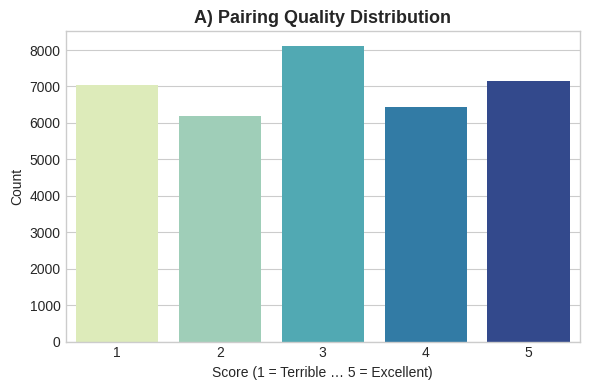

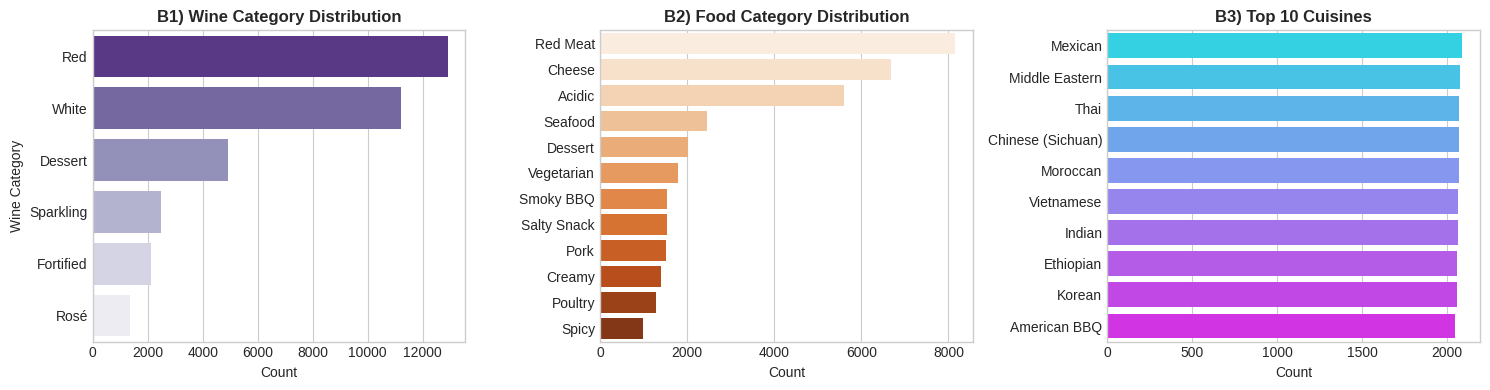

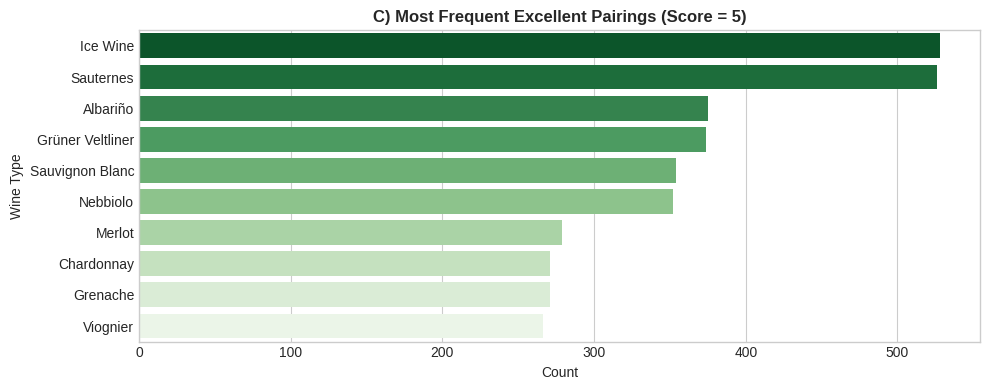

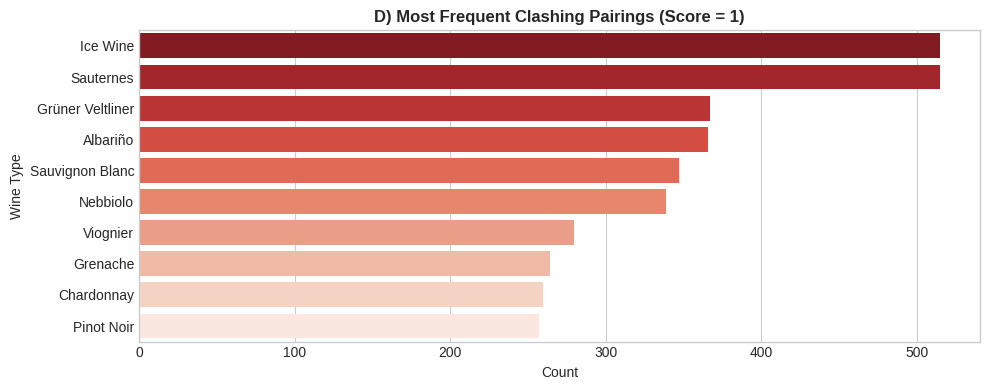

In [12]:
# Load generated dataset
df = pd.read_csv(OUTPUT_PATH)

plt.style.use("seaborn-v0_8-whitegrid")

# --- A) Score Distribution ---
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(
    data=df,
    x="pairing_quality",
    palette="YlGnBu",
    order=sorted(df["pairing_quality"].unique()),
    ax=ax
)
ax.set_title("A) Pairing Quality Distribution", fontsize=13, weight="bold")
ax.set_xlabel("Score (1 = Terrible … 5 = Excellent)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# --- B) Category Diversity ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

sns.countplot(
    data=df,
    y="wine_category",
    order=df["wine_category"].value_counts().index,
    palette="Purples_r",
    ax=axes[0]
)
axes[0].set_title("B1) Wine Category Distribution", weight="bold")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Wine Category")

sns.countplot(
    data=df,
    y="food_category",
    order=df["food_category"].value_counts().index,
    palette="Oranges",
    ax=axes[1]
)
axes[1].set_title("B2) Food Category Distribution", weight="bold")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

sns.countplot(
    data=df,
    y="cuisine",
    order=df["cuisine"].value_counts().index[:10],
    palette="cool",
    ax=axes[2]
)
axes[2].set_title("B3) Top 10 Cuisines", weight="bold")
axes[2].set_xlabel("Count")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

# # --- C) Top Excellent Pairings (Score = 5) ---
# fig, ax = plt.subplots(figsize=(10, 4))
# top_good = df[df["pairing_quality"] == 5]["wine_type"].value_counts().head(10)
# sns.barplot(x=top_good.values, y=top_good.index, palette="Greens_r", ax=ax)
# ax.set_title("C) Most Frequent Excellent Pairings (Score = 5)", weight="bold")
# ax.set_xlabel("Count")
# ax.set_ylabel("Wine Type")
# plt.tight_layout()
# plt.show()

# # --- D) Frequent Clashes (Score = 1) ---
# fig, ax = plt.subplots(figsize=(10, 4))
# top_bad = df[df["pairing_quality"] == 1]["wine_type"].value_counts().head(10)
# sns.barplot(x=top_bad.values, y=top_bad.index, palette="Reds_r", ax=ax)
# ax.set_title("D) Most Frequent Clashing Pairings (Score = 1)", weight="bold")
# ax.set_xlabel("Count")
# ax.set_ylabel("Wine Type")
# plt.tight_layout()
# plt.show()

# --- C) Top Excellent Pairings (Score = 5) ---
fig, ax = plt.subplots(figsize=(10, 4))
top_good = df[df["pairing_quality"] == 5]["wine_type"].value_counts().head(10)

if top_good.empty:
    ax.text(0.5, 0.5, "No Excellent Pairings (Score = 5) Found",
            ha="center", va="center", fontsize=12, color="gray")
    ax.set_axis_off()
else:
    sns.barplot(x=top_good.values, y=top_good.index, palette="Greens_r", ax=ax)
    ax.set_title("C) Most Frequent Excellent Pairings (Score = 5)", weight="bold")
    ax.set_xlabel("Count")
    ax.set_ylabel("Wine Type")

plt.tight_layout()
plt.show()

# --- D) Frequent Clashes (Score = 1) ---
fig, ax = plt.subplots(figsize=(10, 4))
top_bad = df[df["pairing_quality"] == 1]["wine_type"].value_counts().head(10)

if top_bad.empty:
    ax.text(0.5, 0.5, "No Clashing Pairings (Score = 1) Found",
            ha="center", va="center", fontsize=12, color="gray")
    ax.set_axis_off()
else:
    sns.barplot(x=top_bad.values, y=top_bad.index, palette="Reds_r", ax=ax)
    ax.set_title("D) Most Frequent Clashing Pairings (Score = 1)", weight="bold")
    ax.set_xlabel("Count")
    ax.set_ylabel("Wine Type")

plt.tight_layout()
plt.show()



## 📊 Final Thoughts and Next Steps

This notebook demonstrates a **knowledge-driven synthetic data pipeline** — blending culinary logic, sensory science, and AI reasoning.

Possible next steps:
- Add **LLM-based fine-tuning** to auto-generate new foods or pairing explanations
- Incorporate **real datasets** (e.g., wine reviews, restaurant menus)
- Train **pairing recommendation models**
- Visualize **pairing networks** (e.g., by cuisine or archetype similarity)

By publishing both this notebook and dataset, you help the community explore the intersection of **AI and gastronomy** — one of the tastiest areas for creative machine learning!
